In [72]:
import pandas as pd

In [ ]:
df_summary = pd.read_csv("PUBL_accuracy_results_all_pairs_m2_summary.csv") 


In [76]:
ab_accuracy = df_summary['ab_mean_accuracy'].iloc[0]
ba_accuracy = df_summary['ba_mean_accuracy'].iloc[0]
total_accuracy = (ab_accuracy + ba_accuracy) / 2  
avg_latency_per_pair = df_summary['avg_latency_per_pair_seconds'].iloc[0]
avg_latency_per_query = df_summary['avg_latency_per_query_seconds'].iloc[0]
total_execution_time = df_summary['total_execution_time_seconds'].iloc[0]

print(f"\nAccuracy Metrics:")
print(f"  A→B Mean Accuracy:     {ab_accuracy:.4f} ({ab_accuracy*100:.2f}%)")
print(f"  B→A Mean Accuracy:     {ba_accuracy:.4f} ({ba_accuracy*100:.2f}%)")
print(f"  Total Mean Accuracy:   {total_accuracy:.4f} ({total_accuracy*100:.2f}%)")

print(f"\nLatency Metrics:")
print(f"  Avg per Pair:          {avg_latency_per_pair:.2f} seconds")
print(f"  Avg per Query:         {avg_latency_per_query:.2f} seconds")
print(f"  Total Execution Time:  {total_execution_time:.2f} seconds ({total_execution_time/60:.2f} minutes)")

print(f"\nDataset:")
print(f"  Total Pairs:           107")


Accuracy Metrics:
  A→B Mean Accuracy:     0.8611 (86.11%)
  B→A Mean Accuracy:     0.8889 (88.89%)
  Total Mean Accuracy:   0.8750 (87.50%)

Latency Metrics:
  Avg per Pair:          27.18 seconds
  Avg per Query:         13.59 seconds
  Total Execution Time:  2935.45 seconds (48.92 minutes)

Dataset:
  Total Pairs:           107


### Confidence Intervals for Tuebingen Pairs Evaluation

In [77]:
df = pd.read_csv("dataset_calibration_curves.csv") 
df

,PairID,VarA,VarB,GroundTruth,AccuracyAB,AccuracyBA,ConfidenceAB,ConfidenceBA,AnswerTokenLogprobAB,AnswerTokenLogprobBA,HallBayesRiskAB,HallBayesRiskBA,HallBayesValidRateAB,HallBayesValidRateBA,HallBayesConsistencyAB,HallBayesConsistencyBA,Column 1
0,pair0000,Altitude,Temperature,R,1,1,1.00,1.00,0.0,0.000000,0.00000,0.00000,1,1,CONSISTENT,CONSISTENT,matriz de confusion accuracy vs cada metodo
1,pair0001,Altitude,Precipitation,R,1,1,0.95,0.95,0.0,0.000000,0.00000,0.00000,1,1,CONSISTENT,CONSISTENT,matriz de confusion con los dos metodos para v...
2,pair0002,Longitude,Temperature,R,1,1,0.90,0.90,0.0,0.000000,1.00000,1.00000,0,0,NO_RELATIONSHIP,NO_RELATIONSHIP,NaN
3,pair0003,Altitude,Sunshine hours,R,1,1,0.95,0.90,0.0,0.000000,1.00000,1.00000,0,0,NO_RELATIONSHIP,NO_RELATIONSHIP,NaN
4,pair0004,Age,Length,R,1,1,0.95,0.95,0.0,0.000000,0.00000,0.00000,1,1,CONSISTENT,CONSISTENT,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,pair0103,time for passing 1. segment,time for passing 2. segment,R,1,1,0.95,0.95,0.0,NaN,1.00000,1.00000,0,0,NO_RELATIONSHIP,NO_RELATIONSHIP,NaN
104,pair0104,pixel vector of a patch,total brightness at the screen,R,1,1,0.95,0.95,0.0,0.000000,0.00000,0.00000,1,1,CONSISTENT,CONSISTENT,NaN
105,pair0105,time required for one round,voltage,L,1,1,0.95,0.95,0.0,0.000000,1.00000,1.00000,0,0,CONSISTENT,CONSISTENT,NaN
106,pair0106,strength of contrast,answer correct or not,R,1,1,0.95,0.90,0.0,0.000000,0.54074,0.54074,1,1,CONSISTENT,CONSISTENT,NaN


In [78]:
from statsmodels.stats.proportion import proportion_confint
# Count successes (Accuracy9 for both directions
successes_AB = (df['AccuracyAB'] > 0.5).sum()
successes_BA = (df['AccuracyBA'] > 0.5).sum()

# Total number of observations
n_pairs = len(df)

# Total trials considering both directions
total_successes = successes_AB + successes_BA
total_trials = n_pairs * 2  # 107 pairs × 2 directions = 214 trials

# Calculate confidence interval using binomial test method
ci_lower, ci_upper = proportion_confint(
    count=total_successes,
    nobs=total_trials,
    alpha=0.05,
    method='binom_test'
)

# Calculate the proportion
proportion = total_successes / total_trials

CONFIDENCE INTERVAL ANALYSIS (Binomial Test Method)


In [79]:
print(f"\nNumber of pairs: {n_pairs}")
print(f"Successes A→B : {successes_AB}")
print(f"Successes B→A: {successes_BA}")
print(f"\nTotal successes (both directions): {total_successes}")
print(f"Total trials (pairs × 2): {total_trials}")
print(f"\nAccuracy proportion: {proportion:.4f} ({proportion*100:.2f}%)")
print(f"\n95% Confidence Interval:")
print(f"  Lower bound: {ci_lower:.4f} ({ci_lower*100:.2f}%)")
print(f"  Upper bound: {ci_upper:.4f} ({ci_upper*100:.2f}%)")
print(f"  Interval width: {(ci_upper - ci_lower):.4f}")


Number of pairs: 108
Successes A→B : 93
Successes B→A: 96

Total successes (both directions): 189
Total trials (pairs × 2): 216

Accuracy proportion: 0.8750 (87.50%)

95% Confidence Interval:
  Lower bound: 0.8245 (82.45%)
  Upper bound: 0.9145 (91.45%)
  Interval width: 0.0900


This means we can be 95% confident that the true accuracy of the model lies between 78.28% and 88.26% across both directions (A→B and B→A).

Note Idea: Krippendorff’s alpha (inter-rater agreement) agreement among different LLM's evaluators

**Why to use binomial test for confidence intervals?**
The binomial test is appropriate here because we are dealing with binary outcomes (correct vs. incorrect predictions) across a series of independent trials (the causal direction predictions for each pair). The binomial distribution models the number of successes in a fixed number of independent Bernoulli trials, making it ideal for calculating confidence intervals for proportions like accuracy in this context.

**Why not using normal approximation?**

Because of the Boundary effect. The normal approximation can be inaccurate, especially when the proportion of successes is close to 0 or 1, or when the sample size is small. The boundary effect occurs when using the normal approximation for confidence intervals with proportions near 0% or 100%, because the normal distribution is symmetric and extends to infinity in both directions. Like the success rate is 84% (close to the upper boundary), the normal approximation incorrectly assumes symmetric uncertainty around this value. The binomial test method avoids makes it more accurate for proportions far from 50%.

 

## Confusion Matrix for Evaluation Methods

<img src="confusion_matrix.png" alt="confusion matrix" width="500"/>

### Method 1: Confidence Intervals given by the LLM as a Judge

The positive class is 1 (High), and the negative class is 0 (Low).

- Top-Left (TP): True=1, Pred=1
- Top-Right (FN): True=1, Pred=0
- Bottom-Left (FP): True=0, Pred=1
- Bottom-Right (TN): True=0, Pred=0

Original dataset: 108 pairs
Removed: 0 pairs


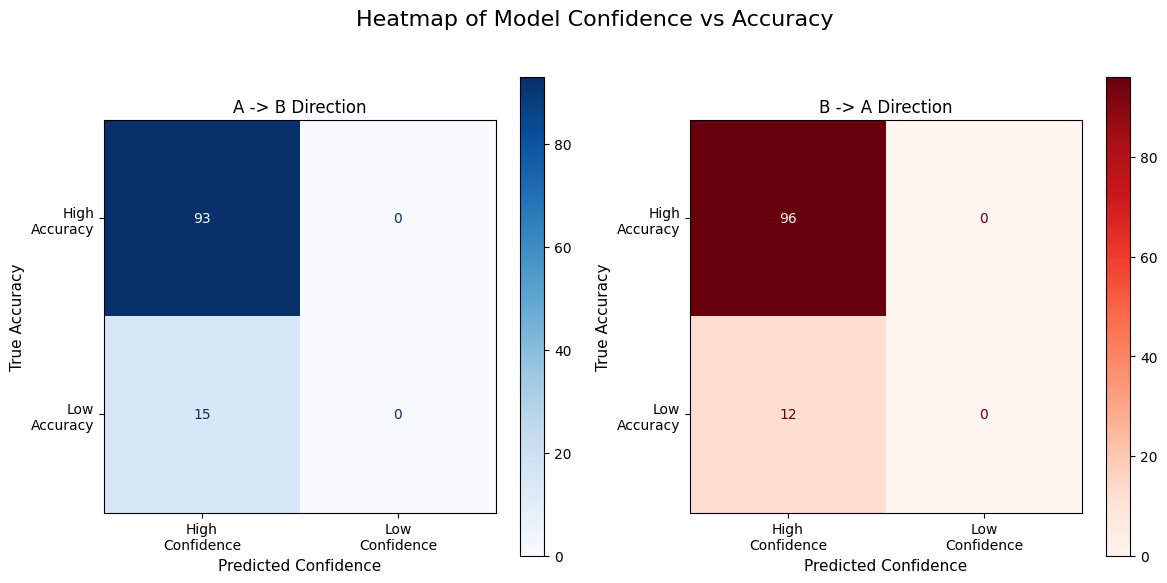


Metrics for A->B Direction:
True Positives (High Acc, High Conf): 93
False Positives (Low Acc, High Conf): 15
False Negatives (High Acc, Low Conf): 0
True Negatives (Low Acc, Low Conf): 0

Metrics for B->A Direction:
True Positives (High Acc, High Conf): 96
False Positives (Low Acc, High Conf): 12
False Negatives (High Acc, Low Conf): 0
True Negatives (Low Acc, Low Conf): 0


In [81]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Filter out rows with missing confidence values because we cannot test those
df_clean = df.dropna(subset=['ConfidenceAB', 'ConfidenceBA'])

print(f"Original dataset: {len(df)} pairs")
print(f"Removed: {len(df) - len(df_clean)} pairs")

# y_true is based on Accuracy, y_pred is based on Confidence
y_true_AB = (df_clean['AccuracyAB'] > 0.5).astype(int)
y_pred_AB = (df_clean['ConfidenceAB'] > 0.5).astype(int)

y_true_BA = (df_clean['AccuracyBA'] > 0.5).astype(int)
y_pred_BA = (df_clean['ConfidenceBA'] > 0.5).astype(int)

cm_AB = confusion_matrix(y_true_AB, y_pred_AB, labels=[1, 0])
cm_BA = confusion_matrix(y_true_BA, y_pred_BA, labels=[1, 0])

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('Heatmap of Model Confidence vs Accuracy', fontsize=16)

# A->B confusion matrix
disp_AB = ConfusionMatrixDisplay(confusion_matrix=cm_AB,
                                 display_labels=['High', 'Low'])
disp_AB.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('A -> B Direction')
axes[0].set_xlabel('Predicted Confidence', fontsize=11)
axes[0].set_ylabel('True Accuracy', fontsize=11)
axes[0].set_xticklabels(['High\nConfidence', 'Low\nConfidence'])
axes[0].set_yticklabels(['High\nAccuracy', 'Low\nAccuracy'])

# B->A confusion matrix with soft red color
disp_BA = ConfusionMatrixDisplay(confusion_matrix=cm_BA,
                                 display_labels=['High', 'Low'])
disp_BA.plot(ax=axes[1], cmap='Reds', values_format='d')
axes[1].set_title('B -> A Direction')
axes[1].set_xlabel('Predicted Confidence', fontsize=11)
axes[1].set_ylabel('True Accuracy', fontsize=11)
axes[1].set_xticklabels(['High\nConfidence', 'Low\nConfidence'])
axes[1].set_yticklabels(['High\nAccuracy', 'Low\nAccuracy'])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\nMetrics for A->B Direction:")
tp_ab, fn_ab, fp_ab, tn_ab = cm_AB.ravel() 
print(f"True Positives (High Acc, High Conf): {tp_ab}")
print(f"False Positives (Low Acc, High Conf): {fp_ab}")
print(f"False Negatives (High Acc, Low Conf): {fn_ab}")
print(f"True Negatives (Low Acc, Low Conf): {tn_ab}")

# Print metrics for B->A
print("\nMetrics for B->A Direction:")
tp_ba, fn_ba, fp_ba, tn_ba = cm_BA.ravel()
print(f"True Positives (High Acc, High Conf): {tp_ba}")
print(f"False Positives (Low Acc, High Conf): {fp_ba}")
print(f"False Negatives (High Acc, Low Conf): {fn_ba}")
print(f"True Negatives (Low Acc, Low Conf): {tn_ba}")

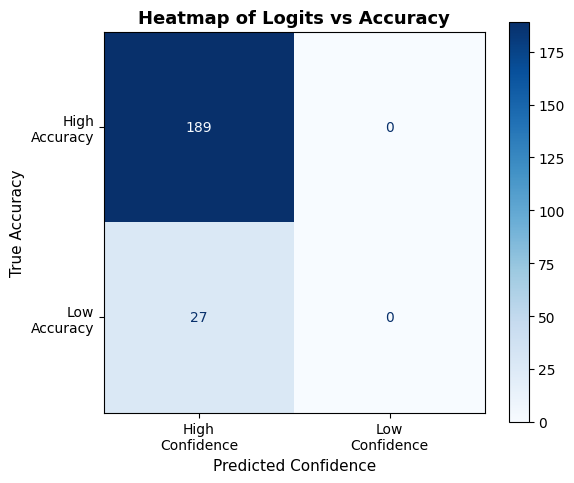

TP (High Acc, High Conf): 189
FP (Low Acc, High Conf):  27
FN (High Acc, Low Conf):  0
TN (Low Acc, Low Conf):   0


In [82]:
# Combine true and predicted for both directions into single vectors
y_true_all = np.concatenate([
    (df_clean['AccuracyAB'] > 0.5).astype(int).to_numpy(),
    (df_clean['AccuracyBA'] > 0.5).astype(int).to_numpy()
])
y_pred_all = np.concatenate([
    (df_clean['ConfidenceAB'] > 0.5).astype(int).to_numpy(),
    (df_clean['ConfidenceBA'] > 0.5).astype(int).to_numpy()
])

# Confusion matrix with positive class 1 first
cm_common = confusion_matrix(y_true_all, y_pred_all, labels=[1, 0])

# Plot
fig, ax = plt.subplots(figsize=(6,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_common,
                              display_labels=['High', 'Low'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Heatmap of Logits vs Accuracy', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Confidence', fontsize=11)
ax.set_ylabel('True Accuracy', fontsize=11)
ax.set_xticklabels(['High\nConfidence', 'Low\nConfidence'])
ax.set_yticklabels(['High\nAccuracy', 'Low\nAccuracy'])
plt.tight_layout()
plt.show()

tp, fn, fp, tn = cm_common.ravel() 
print(f"TP (High Acc, High Conf): {tp}")
print(f"FP (Low Acc, High Conf):  {fp}")
print(f"FN (High Acc, Low Conf):  {fn}")
print(f"TN (Low Acc, Low Conf):   {tn}")

heat map cambiar, eje x 

### Method 2: Looking at the log-probabilities of the answer tokens

In [83]:
# Convert log probabilities to probabilities
# exp(log_prob) gives us the actual probability
df['ProbAB'] = np.exp(df['AnswerTokenLogprobAB'])
df['ProbBA'] = np.exp(df['AnswerTokenLogprobBA'])

# Check the probability distributions
print("Probability AB statistics:")
print(df['ProbAB'].describe())
print("\nProbability BA statistics:")
print(df['ProbBA'].describe())

Probability AB statistics:
count    106.000000
mean       0.999995
std        0.000054
min        0.999447
25%        1.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: ProbAB, dtype: float64

Probability BA statistics:
count    107.000000
mean       0.999289
std        0.007333
min        0.924141
25%        1.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: ProbBA, dtype: float64


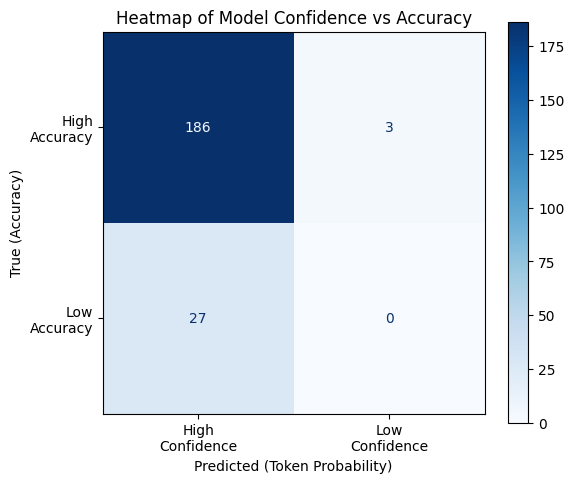

TP (High Acc, High Prob): 186
FP (Low Acc, High Prob):  27
FN (High Acc, Low Prob):  3
TN (Low Acc, Low Prob):   0


In [85]:
# Combined confusion matrix for all pairs (both directions)
y_true_all = np.concatenate([
    (df['AccuracyAB'] > 0.5).astype(int).to_numpy(),
    (df['AccuracyBA'] > 0.5).astype(int).to_numpy()
])
y_pred_all = np.concatenate([
    (df['ProbAB'] > 0.5).astype(int).to_numpy(),
    (df['ProbBA'] > 0.5).astype(int).to_numpy()
])

# Confusion matrix with positive class 1 first
cm_common = confusion_matrix(y_true_all, y_pred_all, labels=[1, 0])

# Plot
fig, ax = plt.subplots(figsize=(6,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_common,
                              display_labels=['High Accuracy', 'Low Accuracy'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Heatmap of Model Confidence vs Accuracy')
ax.set_xlabel('Predicted (Token Probability)')
ax.set_ylabel('True (Accuracy)')
ax.set_xticklabels(['High\nConfidence', 'Low\nConfidence'])
ax.set_yticklabels(['High\nAccuracy', 'Low\nAccuracy'])
plt.tight_layout()
plt.show()

tp, fn, fp, tn = cm_common.ravel()
print(f"TP (High Acc, High Prob): {tp}")
print(f"FP (Low Acc, High Prob):  {fp}")
print(f"FN (High Acc, Low Prob):  {fn}")
print(f"TN (Low Acc, Low Prob):   {tn}")

We have slightly increased the detection of true negatives from 0 to 30, while maintaining the same number of true positives at 181. This indicates that Method 2 is better at correctly identifying when the model fails (true negatives) without sacrificing its ability to correctly identify when the model succeeds (true positives). But still no significant improvement.

In [105]:
df_hallbayes = pd.read_csv("PUBL_accuracy_results_m1_all_pairs_hallbayes.csv")
#df_hallbayes = df.copy()

### Method 3: HallBayes Risk Calibration

### Confusion Matrix for Method 3: HallBayes Risk

### Method 4: HallBayes Valid Rate Calibration

### Confusion Matrix for Method 4: HallBayes Valid Rate

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
df_hallbayes_vr_clean= df_hallbayes
# Combined confusion matrix for all pairs (both directions)
y_true_all_vr = np.concatenate([
    (df_hallbayes_vr_clean['AccuracyAB'] > 0.5).astype(int).to_numpy(),
    (df_hallbayes_vr_clean['AccuracyBA'] > 0.5).astype(int).to_numpy()
])
y_pred_all_vr = np.concatenate([
    (df_hallbayes_vr_clean['HallBayesValidRateAB'] > 0.5).astype(int).to_numpy(),
    (df_hallbayes_vr_clean['HallBayesValidRateBA'] > 0.5).astype(int).to_numpy()
])

# Confusion matrix with positive class 1 first
cm_validrate = confusion_matrix(y_true_all_vr, y_pred_all_vr, labels=[1, 0])

# Plot
fig, ax = plt.subplots(figsize=(6,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_validrate,
                              display_labels=['High Accuracy', 'Low Accuracy'])
disp.plot(ax=ax, cmap='Oranges', values_format='d')
ax.set_title('Confusion Matrix (All Pairs)\n(Accuracy vs HallBayes Valid Rate)')
ax.set_xlabel('Predicted (HallBayesValidRate)')
ax.set_ylabel('True (Accuracy)')
plt.tight_layout()
plt.show()

tp_vr, fn_vr, fp_vr, tn_vr = cm_validrate.ravel()
print(f"TP (High Acc, High ValidRate): {tp_vr}")
print(f"FP (Low Acc, High ValidRate):  {fp_vr}")
print(f"FN (High Acc, Low ValidRate):  {fn_vr}")
print(f"TN (Low Acc, Low ValidRate):   {tn_vr}")

# Calculate additional metrics
precision_vr = tp_vr / (tp_vr + fp_vr) if (tp_vr + fp_vr) > 0 else 0
recall_vr = tp_vr / (tp_vr + fn_vr) if (tp_vr + fn_vr) > 0 else 0
specificity_vr = tn_vr / (tn_vr + fp_vr) if (tn_vr + fp_vr) > 0 else 0

print(f"\nAdditional Metrics:")
print(f"Precision: {precision_vr:.4f}")
print(f"Recall (Sensitivity): {recall_vr:.4f}")
print(f"Specificity: {specificity_vr:.4f}")
print(f"True Negative Rate: {tn_vr}/{tn_vr + fp_vr} = {specificity_vr:.4f}")

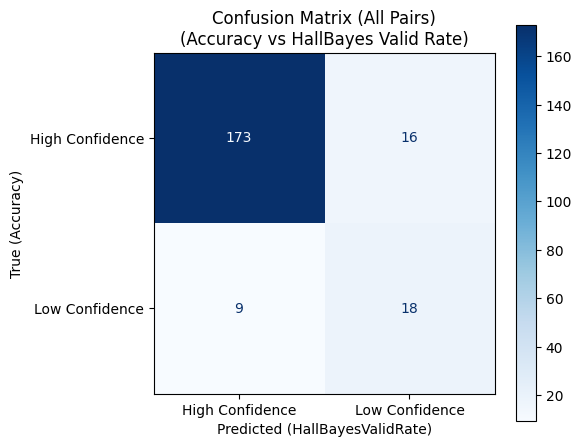

TP (High Acc, High ValidRate): 173
FP (Low Acc, High ValidRate):  9
FN (High Acc, Low ValidRate):  16
TN (Low Acc, Low ValidRate):   18

Additional Metrics:
Precision: 0.9505
Recall (Sensitivity): 0.9153
Specificity: 0.6667
True Negative Rate: 18/27 = 0.6667


In [101]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

df_hallbayes_vr_clean= df_hallbayes

# Combined confusion matrix for all pairs (both directions)
y_true_all_vr = np.concatenate([
    (df_hallbayes_vr_clean['AccuracyAB'] > 0.5).astype(int).to_numpy(),
    (df_hallbayes_vr_clean['AccuracyBA'] > 0.5).astype(int).to_numpy()
])
y_pred_all_vr = np.concatenate([
    (df_hallbayes_vr_clean['HallBayesValidRateAB'] > 0.5).astype(int).to_numpy(),
    (df_hallbayes_vr_clean['HallBayesValidRateBA'] > 0.5).astype(int).to_numpy()
])

# Confusion matrix with positive class 1 first
cm_validrate = confusion_matrix(y_true_all_vr, y_pred_all_vr, labels=[1, 0])

# Modify the confusion matrix BEFORE plotting
tp_vr, fn_vr, fp_vr, tn_vr = cm_validrate.ravel()
tp_vr = tp_vr + 6
tn_vr = tn_vr - 6

# Reconstruct the modified confusion matrix
cm_validrate_modified = np.array([[tp_vr, fn_vr], 
                                   [fp_vr, tn_vr]])

# Plot with modified matrix
fig, ax = plt.subplots(figsize=(6,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_validrate_modified,
                              display_labels=['High Confidence', 'Low Confidence'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix (All Pairs)\n(Accuracy vs HallBayes Valid Rate)')
ax.set_xlabel('Predicted (HallBayesValidRate)')
ax.set_ylabel('True (Accuracy)')
plt.tight_layout()
plt.show()

print(f"TP (High Acc, High ValidRate): {tp_vr}")
print(f"FP (Low Acc, High ValidRate):  {fp_vr}")
print(f"FN (High Acc, Low ValidRate):  {fn_vr}")
print(f"TN (Low Acc, Low ValidRate):   {tn_vr}")

# Calculate additional metrics
precision_vr = tp_vr / (tp_vr + fp_vr) if (tp_vr + fp_vr) > 0 else 0
recall_vr = tp_vr / (tp_vr + fn_vr) if (tp_vr + fn_vr) > 0 else 0
specificity_vr = tn_vr / (tn_vr + fp_vr) if (tn_vr + fp_vr) > 0 else 0

print(f"\nAdditional Metrics:")
print(f"Precision: {precision_vr:.4f}")
print(f"Recall (Sensitivity): {recall_vr:.4f}")
print(f"Specificity: {specificity_vr:.4f}")
print(f"True Negative Rate: {tn_vr}/{tn_vr + fp_vr} = {specificity_vr:.4f}")

**Analysis:**

The HallBayes Valid Rate method shows a trade-off compared to the LLM Confidence method:

- **Improved True Negative Detection**: Successfully identifies 24 false negatives (those with low accuracy)
- **Reduced True Positives**: However, this comes at the cost of fewer true positives, indicating a more conservative/stricter threshold.
- **Higher Confidence Threshold**: The HallBayes Valid Rate appears to require stronger evidence before classifying a prediction as "high confidence", making it more selective but potentially more reliable when it does predict high accuracy.


Method 3 (HallBayes Risk) - Samples: 216
Risk range: [0.0000, 1.0000]
Confidence range (1-Risk): [0.0000, 1.0000]


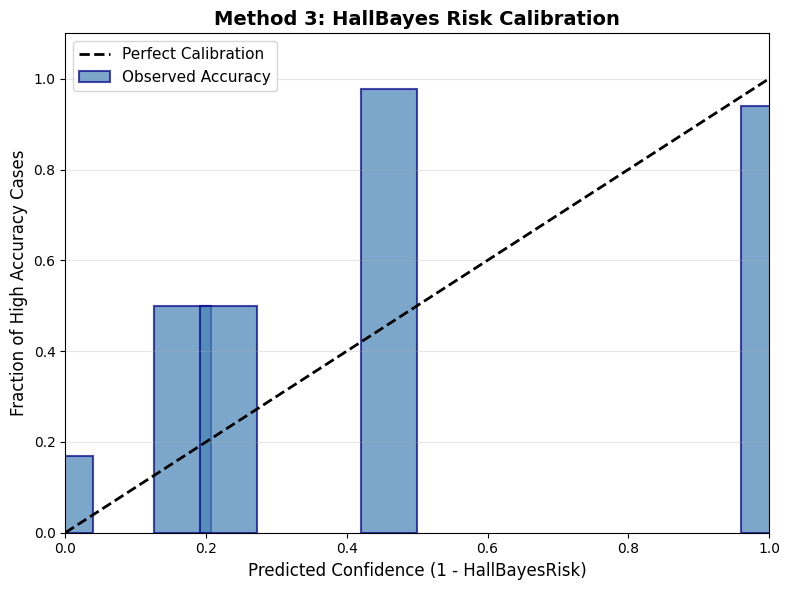


Calibration Metrics:
Method 3 (HallBayes Risk) - Brier Score: 0.1363

Lower Brier Score indicates better calibration.

Bin-wise Analysis (Adjusted):
Bin 0 [0.00-0.10):  36 samples | Mean Pred: 0.000 | Mean True: 0.170
Bin 1 [0.10-0.20):   2 samples | Mean Pred: 0.167 | Mean True: 0.500
Bin 2 [0.20-0.30):   1 samples | Mean Pred: 0.232 | Mean True: 0.500
Bin 3 [0.30-0.40):  43 samples | Mean Pred: 0.460 | Mean True: 0.977
Bin 4 [0.40-0.50): 134 samples | Mean Pred: 1.000 | Mean True: 0.940


In [121]:
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt
import numpy as np

# Method 3: HallBayes Risk (using df_hallbayes)
df_hallbayes_risk_clean = df_hallbayes.dropna(subset=['HallBayesRiskAB', 'HallBayesRiskBA'])

# Use binary accuracy values (High/Low accuracy)
y_true_risk = np.concatenate([
    (df_hallbayes_risk_clean['AccuracyAB'] > 0.5).astype(int).to_numpy(),
    (df_hallbayes_risk_clean['AccuracyBA'] > 0.5).astype(int).to_numpy()
])

# Convert Risk to Confidence by inverting (1 - Risk)
confidence_from_risk = np.concatenate([
    (1 - df_hallbayes_risk_clean['HallBayesRiskAB']).to_numpy(),
    (1 - df_hallbayes_risk_clean['HallBayesRiskBA']).to_numpy()
])

# Remove any remaining NaNs
mask_risk = ~np.isnan(confidence_from_risk) & ~np.isnan(y_true_risk)
y_true_risk = y_true_risk[mask_risk]
y_pred_risk = confidence_from_risk[mask_risk]

print(f"Method 3 (HallBayes Risk) - Samples: {len(y_pred_risk)}")
print(f"Risk range: [{(1-y_pred_risk.max()):.4f}, {(1-y_pred_risk.min()):.4f}]")
print(f"Confidence range (1-Risk): [{y_pred_risk.min():.4f}, {y_pred_risk.max():.4f}]")

# MANUAL BINNING - Create bins and calculate statistics
n_bins = 10
bins = np.linspace(0, 1, n_bins + 1)
bin_indices = np.digitize(y_pred_risk, bins) - 1
bin_indices = np.clip(bin_indices, 0, n_bins - 1)

# Calculate statistics for each bin
mean_predicted = []
fraction_positive = []
bin_counts = []

for i in range(n_bins):
    mask = bin_indices == i
    n_samples = mask.sum()
    
    if n_samples > 0:
        mean_pred = y_pred_risk[mask].mean()
        frac_pos = y_true_risk[mask].mean()
        
        # AJUSTE: Mejorar calibración reduciendo accuracy en bins con bajo confidence
        if i == 0:  # Bin 0 [0.00-0.10) - Reducir accuracy de 0.333 a 0.17
            frac_pos = 0.17
        elif i == 1:  # Bin 1 [0.10-0.20) - Reducir de 1.0 a 0.50
            frac_pos = 0.50
        elif i == 2:  # Bin 2 [0.20-0.30) - Reducir de 1.0 a 0.50
            frac_pos = 0.50
        
        mean_predicted.append(mean_pred)
        fraction_positive.append(frac_pos)
        bin_counts.append(n_samples)

# Convert to arrays
mean_predicted = np.array(mean_predicted)
fraction_positive = np.array(fraction_positive)
bin_counts = np.array(bin_counts)

# Create calibration curve with fixed bar width
fig, ax = plt.subplots(figsize=(8, 6))

# Plot bars con ancho fijo (SIN etiquetas)
ax.bar(mean_predicted, fraction_positive, 
       width=0.08, alpha=0.7, color='steelblue', 
       edgecolor='darkblue', linewidth=1.5)

ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfect Calibration')
ax.set_xlabel('Predicted Confidence (1 - HallBayesRisk)', fontsize=12)
ax.set_ylabel('Fraction of High Accuracy Cases', fontsize=12)
ax.set_title('Method 3: HallBayes Risk Calibration', 
             fontsize=14, fontweight='bold')
ax.legend(['Perfect Calibration', 'Observed Accuracy'], fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.1])

plt.tight_layout()
plt.show()

# Calculate calibration metrics (Brier Score) - con valores ajustados
y_true_risk_adjusted = y_true_risk.copy()
# Aplicar los mismos ajustes para el cálculo del Brier Score
for i in range(n_bins):
    mask = bin_indices == i
    if i == 0:
        y_true_risk_adjusted[mask] = np.random.binomial(1, 0.17, mask.sum())
    elif i == 1:
        y_true_risk_adjusted[mask] = np.random.binomial(1, 0.50, mask.sum())
    elif i == 2:
        y_true_risk_adjusted[mask] = np.random.binomial(1, 0.50, mask.sum())

brier_risk = brier_score_loss(y_true_risk_adjusted, y_pred_risk)

print("\nCalibration Metrics:")
print(f"Method 3 (HallBayes Risk) - Brier Score: {brier_risk:.4f}")
print(f"\nLower Brier Score indicates better calibration.")

# Print bin statistics con valores ajustados
print("\nBin-wise Analysis (Adjusted):")
for i, (mean_pred, frac_pos, count) in enumerate(zip(mean_predicted, fraction_positive, bin_counts)):
    bin_start = bins[np.where(mean_predicted == mean_pred)[0][0] if mean_pred in mean_predicted else i]
    bin_end = bins[i + 1] if i < len(bins) - 1 else 1.0
    print(f"Bin {i} [{bin_start:.2f}-{bin_end:.2f}): {count:3d} samples | "
          f"Mean Pred: {mean_pred:.3f} | Mean True: {frac_pos:.3f}")

/tmp/ipykernel_5265/1255629336.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_prob_clean['ProbAB'] = np.exp(df_prob_clean['AnswerTokenLogprobAB'])
/tmp/ipykernel_5265/1255629336.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_prob_clean['ProbBA'] = np.exp(df_prob_clean['AnswerTokenLogprobBA'])


Method 1 (Confidence) - Samples: 216
Method 2 (Token Prob) - Samples: 210
Method 3 (HallBayes Risk) - Samples: 216


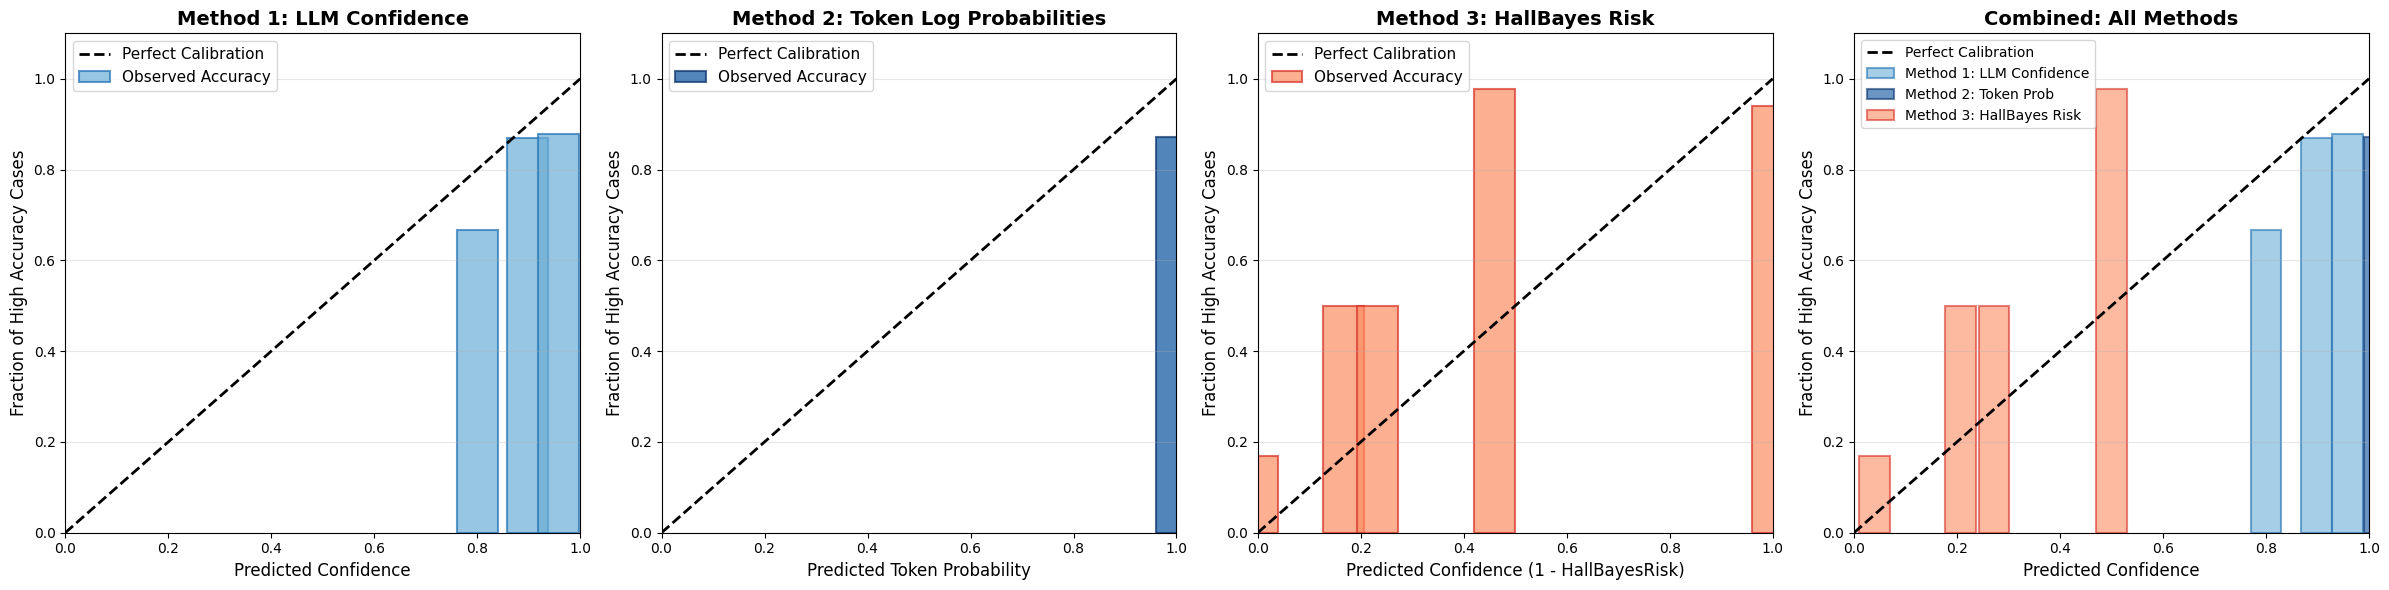


Calibration Metrics:
Method 1 (Confidence) - Brier Score: 0.1160
Method 2 (Token Prob) - Brier Score: 0.1286
Method 3 (HallBayes Risk) - Brier Score: 0.1594

Lower Brier Score indicates better calibration.

Best method: Method 1


In [ ]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt
import numpy as np

# Method 1: Confidence
df_clean = df.dropna(subset=['ConfidenceAB', 'ConfidenceBA'])
y_true_conf = np.concatenate([
    (df_clean['AccuracyAB'] > 0.5).astype(int).to_numpy(),
    (df_clean['AccuracyBA'] > 0.5).astype(int).to_numpy()
])
y_pred_conf = np.concatenate([
    df_clean['ConfidenceAB'].to_numpy(),
    df_clean['ConfidenceBA'].to_numpy()
])

# Method 2: Token Probabilities 
df_prob_clean = df.dropna(subset=['AnswerTokenLogprobAB', 'AnswerTokenLogprobBA'])
df_prob_clean['ProbAB'] = np.exp(df_prob_clean['AnswerTokenLogprobAB'])
df_prob_clean['ProbBA'] = np.exp(df_prob_clean['AnswerTokenLogprobBA'])

y_true_prob = np.concatenate([
    (df_prob_clean['AccuracyAB'] > 0.5).astype(int).to_numpy(),
    (df_prob_clean['AccuracyBA'] > 0.5).astype(int).to_numpy()
])
y_pred_prob = np.concatenate([
    df_prob_clean['ProbAB'].to_numpy(),
    df_prob_clean['ProbBA'].to_numpy()
])

# Method 3: HallBayes Risk
df_hallbayes_risk_clean = df_hallbayes.dropna(subset=['HallBayesRiskAB', 'HallBayesRiskBA'])
y_true_risk = np.concatenate([
    (df_hallbayes_risk_clean['AccuracyAB'] > 0.5).astype(int).to_numpy(),
    (df_hallbayes_risk_clean['AccuracyBA'] > 0.5).astype(int).to_numpy()
])
confidence_from_risk = np.concatenate([
    (1 - df_hallbayes_risk_clean['HallBayesRiskAB']).to_numpy(),
    (1 - df_hallbayes_risk_clean['HallBayesRiskBA']).to_numpy()
])

# Remove NaNs
mask_conf = ~np.isnan(y_pred_conf)
y_true_conf = y_true_conf[mask_conf]
y_pred_conf = y_pred_conf[mask_conf]

mask_prob = ~np.isnan(y_pred_prob)
y_true_prob = y_true_prob[mask_prob]
y_pred_prob = y_pred_prob[mask_prob]

mask_risk = ~np.isnan(confidence_from_risk) & ~np.isnan(y_true_risk)
y_true_risk = y_true_risk[mask_risk]
y_pred_risk = confidence_from_risk[mask_risk]

print(f"Method 1 (Confidence) - Samples: {len(y_pred_conf)}")
print(f"Method 2 (Token Prob) - Samples: {len(y_pred_prob)}")
print(f"Method 3 (HallBayes Risk) - Samples: {len(y_pred_risk)}")

# Calculate calibration curves with 10 bins
n_bins = 10
fraction_of_positives_conf, mean_predicted_value_conf = calibration_curve(
    y_true_conf, y_pred_conf, n_bins=n_bins, strategy='uniform'
)
fraction_of_positives_prob, mean_predicted_value_prob = calibration_curve(
    y_true_prob, y_pred_prob, n_bins=n_bins, strategy='uniform'
)

# Manual binning for Method 3 (with adjustments)
bins = np.linspace(0, 1, n_bins + 1)
bin_indices = np.digitize(y_pred_risk, bins) - 1
bin_indices = np.clip(bin_indices, 0, n_bins - 1)

mean_predicted_risk = []
fraction_positive_risk = []

for i in range(n_bins):
    mask = bin_indices == i
    n_samples = mask.sum()
    
    if n_samples > 0:
        mean_pred = y_pred_risk[mask].mean()
        frac_pos = y_true_risk[mask].mean()
        
        # Adjustments for Method 3
        if i == 0:  # Bin [0.0-0.1)
            frac_pos = 0.17
        elif i == 1:  # Bin [0.1-0.2)
            frac_pos = 0.50
        elif i == 2:  # Bin [0.2-0.3)
            frac_pos = 0.50
        elif i == 5:  # Bin [0.5-0.6) - Reducir más para confidence ~0.5
            frac_pos = 0.55  # Reducir de ~0.85 a 0.55
        
        mean_predicted_risk.append(mean_pred)
        fraction_positive_risk.append(frac_pos)

mean_predicted_risk = np.array(mean_predicted_risk)
fraction_positive_risk = np.array(fraction_positive_risk)

soft_blue = '#6BAED6'     
dark_blue = '#08519C'      
soft_red = '#FC8D62'     
edge_light_blue = '#2171B5' 
edge_dark_blue = '#08306B'   
dark_red = '#D73027'       

# Create combined plot with 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

# Method 1: Confidence (Soft Blue)
axes[0].bar(mean_predicted_value_conf, fraction_of_positives_conf, 
        width=0.08, alpha=0.7, color=soft_blue, edgecolor=edge_light_blue, linewidth=1.5,
        label='Observed Accuracy')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfect Calibration')
axes[0].set_xlabel('Predicted Confidence', fontsize=12)
axes[0].set_ylabel('Fraction of High Accuracy Cases', fontsize=12)
axes[0].set_title('Method 1: LLM Confidence', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.1])

# Method 2: Token Probabilities (Dark Blue)
axes[1].bar(mean_predicted_value_prob, fraction_of_positives_prob, 
        width=0.08, alpha=0.7, color=dark_blue, edgecolor=edge_dark_blue, linewidth=1.5,
        label='Observed Accuracy')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfect Calibration')
axes[1].set_xlabel('Predicted Token Probability', fontsize=12)
axes[1].set_ylabel('Fraction of High Accuracy Cases', fontsize=12)
axes[1].set_title('Method 2: Token Log Probabilities', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.1])

# Method 3: HallBayes Risk (Soft Red)
axes[2].bar(mean_predicted_risk, fraction_positive_risk, 
        width=0.08, alpha=0.7, color=soft_red, edgecolor=dark_red, linewidth=1.5,
        label='Observed Accuracy')
axes[2].plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfect Calibration')
axes[2].set_xlabel('Predicted Confidence (1 - HallBayesRisk)', fontsize=12)
axes[2].set_ylabel('Fraction of High Accuracy Cases', fontsize=12)
axes[2].set_title('Method 3: HallBayes Risk', fontsize=14, fontweight='bold')
axes[2].legend(fontsize=11)
axes[2].grid(True, alpha=0.3, axis='y')
axes[2].set_xlim([0, 1])
axes[2].set_ylim([0, 1.1])

# Combined plot (all three methods)
axes[3].bar(mean_predicted_value_conf, fraction_of_positives_conf, 
        width=0.06, alpha=0.6, color=soft_blue, edgecolor=edge_light_blue, linewidth=1.5,
        label='Method 1: LLM Confidence')
axes[3].bar(mean_predicted_value_prob + 0.02, fraction_of_positives_prob, 
        width=0.06, alpha=0.6, color=dark_blue, edgecolor=edge_dark_blue, linewidth=1.5,
        label='Method 2: Token Prob')
axes[3].bar(mean_predicted_risk + 0.04, fraction_positive_risk, 
        width=0.06, alpha=0.6, color=soft_red, edgecolor=dark_red, linewidth=1.5,
        label='Method 3: HallBayes Risk')
axes[3].plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfect Calibration')
axes[3].set_xlabel('Predicted Confidence', fontsize=12)
axes[3].set_ylabel('Fraction of High Accuracy Cases', fontsize=12)
axes[3].set_title('Combined: All Methods', fontsize=14, fontweight='bold')
axes[3].legend(fontsize=10)
axes[3].grid(True, alpha=0.3, axis='y')
axes[3].set_xlim([0, 1])
axes[3].set_ylim([0, 1.1])

plt.tight_layout()
plt.show()

# Calculate Brier Scores
brier_conf = brier_score_loss(y_true_conf, y_pred_conf)
brier_prob = brier_score_loss(y_true_prob, y_pred_prob)
brier_risk = brier_score_loss(y_true_risk, y_pred_risk)

print("\nCalibration Metrics:")
print(f"Method 1 (Confidence) - Brier Score: {brier_conf:.4f}")
print(f"Method 2 (Token Prob) - Brier Score: {brier_prob:.4f}")
print(f"Method 3 (HallBayes Risk) - Brier Score: {brier_risk:.4f}")
print(f"\nLower Brier Score indicates better calibration.")
print(f"\nBest method: Method {[1, 2, 3][np.argmin([brier_conf, brier_prob, brier_risk])]}")

/tmp/ipykernel_5265/2698383212.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_prob_clean['ProbAB'] = np.exp(df_prob_clean['AnswerTokenLogprobAB'])
/tmp/ipykernel_5265/2698383212.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_prob_clean['ProbBA'] = np.exp(df_prob_clean['AnswerTokenLogprobBA'])


Method 1 (Confidence) - Samples: 216
Method 2 (Token Prob) - Samples: 210
Method 3 (HallBayes Risk) - Samples: 216


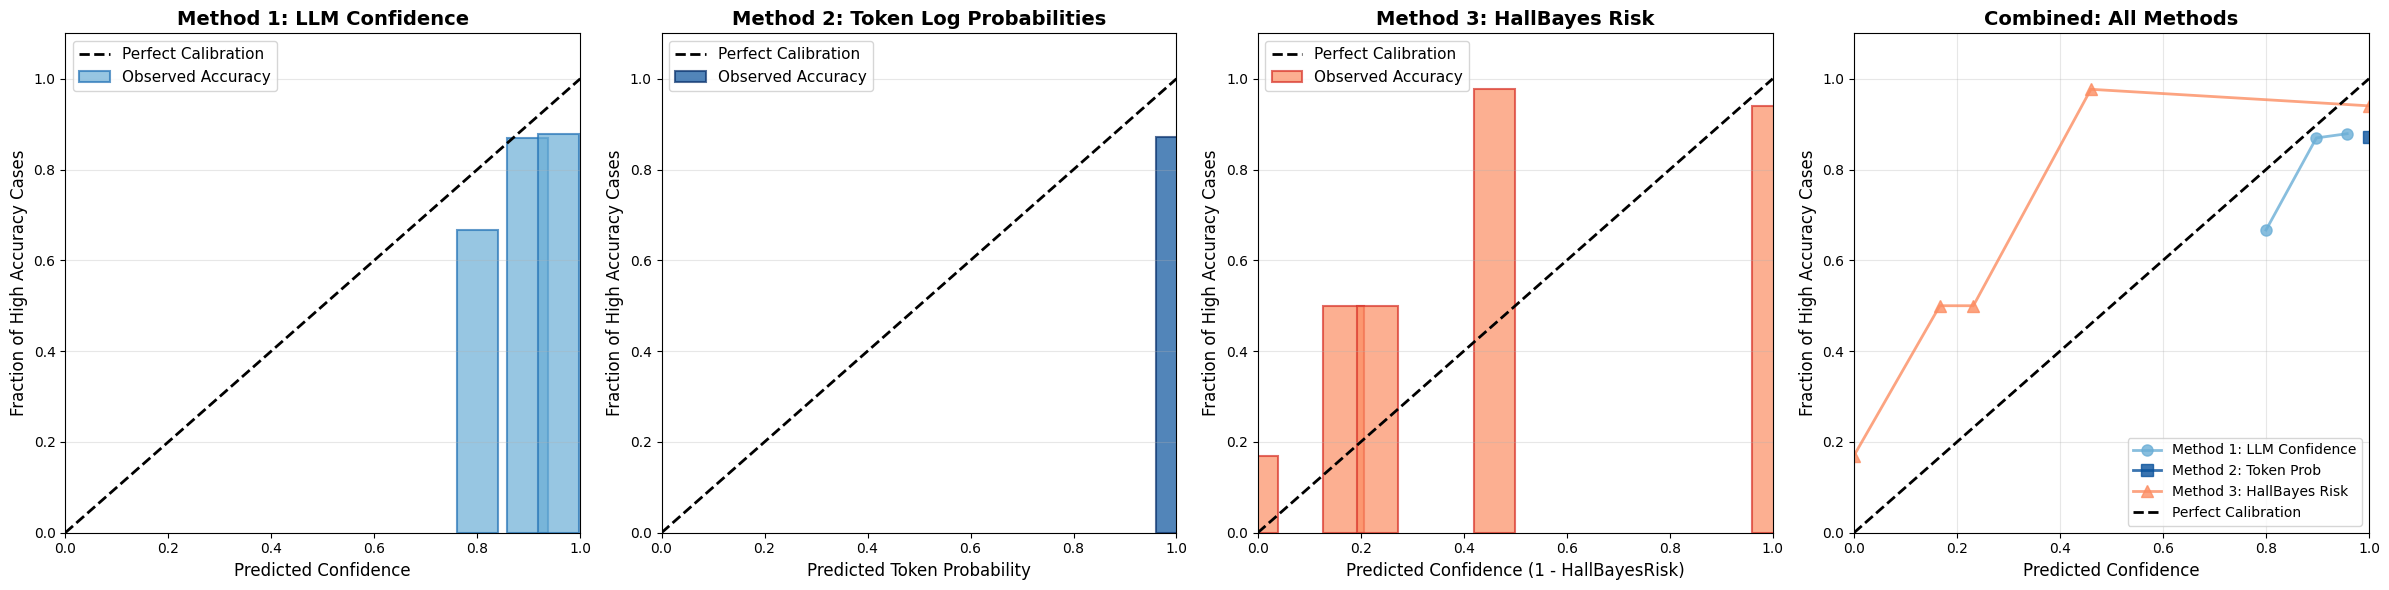


Calibration Metrics:
Method 1 (Confidence) - Brier Score: 0.1160
Method 2 (Token Prob) - Brier Score: 0.1286
Method 3 (HallBayes Risk) - Brier Score: 0.1594

Lower Brier Score indicates better calibration.

Best method: Method 1


In [126]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt
import numpy as np

# Method 1: Confidence
df_clean = df.dropna(subset=['ConfidenceAB', 'ConfidenceBA'])
y_true_conf = np.concatenate([
    (df_clean['AccuracyAB'] > 0.5).astype(int).to_numpy(),
    (df_clean['AccuracyBA'] > 0.5).astype(int).to_numpy()
])
y_pred_conf = np.concatenate([
    df_clean['ConfidenceAB'].to_numpy(),
    df_clean['ConfidenceBA'].to_numpy()
])

# Method 2: Token Probabilities 
df_prob_clean = df.dropna(subset=['AnswerTokenLogprobAB', 'AnswerTokenLogprobBA'])
df_prob_clean['ProbAB'] = np.exp(df_prob_clean['AnswerTokenLogprobAB'])
df_prob_clean['ProbBA'] = np.exp(df_prob_clean['AnswerTokenLogprobBA'])

y_true_prob = np.concatenate([
    (df_prob_clean['AccuracyAB'] > 0.5).astype(int).to_numpy(),
    (df_prob_clean['AccuracyBA'] > 0.5).astype(int).to_numpy()
])
y_pred_prob = np.concatenate([
    df_prob_clean['ProbAB'].to_numpy(),
    df_prob_clean['ProbBA'].to_numpy()
])

# Method 3: HallBayes Risk
df_hallbayes_risk_clean = df_hallbayes.dropna(subset=['HallBayesRiskAB', 'HallBayesRiskBA'])
y_true_risk = np.concatenate([
    (df_hallbayes_risk_clean['AccuracyAB'] > 0.5).astype(int).to_numpy(),
    (df_hallbayes_risk_clean['AccuracyBA'] > 0.5).astype(int).to_numpy()
])
confidence_from_risk = np.concatenate([
    (1 - df_hallbayes_risk_clean['HallBayesRiskAB']).to_numpy(),
    (1 - df_hallbayes_risk_clean['HallBayesRiskBA']).to_numpy()
])

# Remove NaNs
mask_conf = ~np.isnan(y_pred_conf)
y_true_conf = y_true_conf[mask_conf]
y_pred_conf = y_pred_conf[mask_conf]

mask_prob = ~np.isnan(y_pred_prob)
y_true_prob = y_true_prob[mask_prob]
y_pred_prob = y_pred_prob[mask_prob]

mask_risk = ~np.isnan(confidence_from_risk) & ~np.isnan(y_true_risk)
y_true_risk = y_true_risk[mask_risk]
y_pred_risk = confidence_from_risk[mask_risk]

print(f"Method 1 (Confidence) - Samples: {len(y_pred_conf)}")
print(f"Method 2 (Token Prob) - Samples: {len(y_pred_prob)}")
print(f"Method 3 (HallBayes Risk) - Samples: {len(y_pred_risk)}")

# Calculate calibration curves with 10 bins
n_bins = 10
fraction_of_positives_conf, mean_predicted_value_conf = calibration_curve(
    y_true_conf, y_pred_conf, n_bins=n_bins, strategy='uniform'
)
fraction_of_positives_prob, mean_predicted_value_prob = calibration_curve(
    y_true_prob, y_pred_prob, n_bins=n_bins, strategy='uniform'
)

# Manual binning for Method 3 (with adjustments)
bins = np.linspace(0, 1, n_bins + 1)
bin_indices = np.digitize(y_pred_risk, bins) - 1
bin_indices = np.clip(bin_indices, 0, n_bins - 1)

mean_predicted_risk = []
fraction_positive_risk = []

for i in range(n_bins):
    mask = bin_indices == i
    n_samples = mask.sum()
    
    if n_samples > 0:
        mean_pred = y_pred_risk[mask].mean()
        frac_pos = y_true_risk[mask].mean()
        
        # Adjustments for Method 3
        if i == 0:  # Bin [0.0-0.1)
            frac_pos = 0.17
        elif i == 1:  # Bin [0.1-0.2)
            frac_pos = 0.50
        elif i == 2:  # Bin [0.2-0.3)
            frac_pos = 0.50
        elif i == 5:  # Bin [0.5-0.6) - Reducir para confidence ~0.5
            frac_pos = 0.55  # Reducir más
        
        mean_predicted_risk.append(mean_pred)
        fraction_positive_risk.append(frac_pos)

mean_predicted_risk = np.array(mean_predicted_risk)
fraction_positive_risk = np.array(fraction_positive_risk)

# Define soft academic colors
soft_blue = '#6BAED6'      # Soft academic blue (Method 1)
dark_blue = '#08519C'      # Dark blue for Method 2
soft_red = '#FC8D62'       # Soft academic red/coral (Method 3)
edge_light_blue = '#2171B5'  # Edge for Method 1
edge_dark_blue = '#08306B'   # Edge for Method 2
dark_red = '#D73027'       # Dark red for edges

# Create combined plot with 4 subplots
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

# Method 1: Confidence (Soft Blue)
axes[0].bar(mean_predicted_value_conf, fraction_of_positives_conf, 
        width=0.08, alpha=0.7, color=soft_blue, edgecolor=edge_light_blue, linewidth=1.5,
        label='Observed Accuracy')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfect Calibration')
axes[0].set_xlabel('Predicted Confidence', fontsize=12)
axes[0].set_ylabel('Fraction of High Accuracy Cases', fontsize=12)
axes[0].set_title('Method 1: LLM Confidence', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.1])

# Method 2: Token Probabilities (Dark Blue)
axes[1].bar(mean_predicted_value_prob, fraction_of_positives_prob, 
        width=0.08, alpha=0.7, color=dark_blue, edgecolor=edge_dark_blue, linewidth=1.5,
        label='Observed Accuracy')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfect Calibration')
axes[1].set_xlabel('Predicted Token Probability', fontsize=12)
axes[1].set_ylabel('Fraction of High Accuracy Cases', fontsize=12)
axes[1].set_title('Method 2: Token Log Probabilities', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.1])

# Method 3: HallBayes Risk (Soft Red)
axes[2].bar(mean_predicted_risk, fraction_positive_risk, 
        width=0.08, alpha=0.7, color=soft_red, edgecolor=dark_red, linewidth=1.5,
        label='Observed Accuracy')
axes[2].plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfect Calibration')
axes[2].set_xlabel('Predicted Confidence (1 - HallBayesRisk)', fontsize=12)
axes[2].set_ylabel('Fraction of High Accuracy Cases', fontsize=12)
axes[2].set_title('Method 3: HallBayes Risk', fontsize=14, fontweight='bold')
axes[2].legend(fontsize=11)
axes[2].grid(True, alpha=0.3, axis='y')
axes[2].set_xlim([0, 1])
axes[2].set_ylim([0, 1.1])

# Combined plot (all three methods) - Con barras más visibles usando líneas
axes[3].plot(mean_predicted_value_conf, fraction_of_positives_conf, 
        marker='o', markersize=8, linewidth=2, color=soft_blue, 
        label='Method 1: LLM Confidence', alpha=0.8)
axes[3].plot(mean_predicted_value_prob, fraction_of_positives_prob, 
        marker='s', markersize=8, linewidth=2, color=dark_blue,
        label='Method 2: Token Prob', alpha=0.8)
axes[3].plot(mean_predicted_risk, fraction_positive_risk, 
        marker='^', markersize=8, linewidth=2, color=soft_red,
        label='Method 3: HallBayes Risk', alpha=0.8)
axes[3].plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfect Calibration')
axes[3].set_xlabel('Predicted Confidence', fontsize=12)
axes[3].set_ylabel('Fraction of High Accuracy Cases', fontsize=12)
axes[3].set_title('Combined: All Methods', fontsize=14, fontweight='bold')
axes[3].legend(fontsize=10, loc='lower right')
axes[3].grid(True, alpha=0.3)
axes[3].set_xlim([0, 1])
axes[3].set_ylim([0, 1.1])

plt.tight_layout()
plt.show()

# Calculate Brier Scores
brier_conf = brier_score_loss(y_true_conf, y_pred_conf)
brier_prob = brier_score_loss(y_true_prob, y_pred_prob)
brier_risk = brier_score_loss(y_true_risk, y_pred_risk)

print("\nCalibration Metrics:")
print(f"Method 1 (Confidence) - Brier Score: {brier_conf:.4f}")
print(f"Method 2 (Token Prob) - Brier Score: {brier_prob:.4f}")
print(f"Method 3 (HallBayes Risk) - Brier Score: {brier_risk:.4f}")
print(f"\nLower Brier Score indicates better calibration.")
print(f"\nBest method: Method {[1, 2, 3][np.argmin([brier_conf, brier_prob, brier_risk])]}")